<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/telecom_italia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/telecom_italia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `telecom_italia`: HCF·G.654.E·SMF 해저 비교와 Telecom Italia Field Trial GN 재현

이 노트북은 기존 HCF 계산 코드를 변경하지 않고 복사하여 확장한 별도 실행본이다. 앞부분은 HCF Fig. 2 재현과 1,000 km 해저구간의 리피터·용량 비교를 유지하고, 뒷부분은 첨부 논문 Chapter 6.1의 Telecom Italia field trial을 사용자의 GN 모델로 교차검증한다.


In [1]:
%pip -q install numpy scipy matplotlib


## 실행 및 수정 방법

1. 아래 설치 셀을 실행합니다.
2. 그다음 모델 셀을 실행하면 `fig2_hcf_colab.png`가 저장되고 그래프가 표시됩니다.
3. 조건을 바꾸려면 모델 셀의 `HCFLink` 데이터클래스 값을 수정합니다. 예: `n_channels`, `span_length_km`, `transceiver_snr_db`, `nonlinear_coefficient_per_w_km`.

기본 계산 범위는 논문 Fig. 2와 동일하게 $-40$~$50$ dBm/channel입니다.

실행 결과에는 8개 검증점의 논문값·계산값·상대오차 표도 함께 출력됩니다.


=== Fig. 2 HCF calculation ===
Channels / baud rate / spacing : 29 / 140 GBd / 150 GHz
C-band channel wavelengths     : 1530.71–1564.26 nm
HCF attenuation across grid    : 0.0743–0.0762 dB/km
HCF dispersion across grid     : 3.1018–3.2746 ps/(nm·km)
GN eta across grid             : 1.679e-04–1.784e-04 1/W²
ASE per channel                : -27.55 dBm (mean)
Maximum throughput             : 52.671 Tb/s
Launch power at maximum        : 22.32 dBm/channel

=== Comparison with paper's vector curve ===
 Pch (dBm) | Paper (Tb/s) | Model (Tb/s) | Error (%)
------------+--------------+--------------+----------
      -35.0 |       1.8729 |       1.9379 |   +3.471
      -20.0 |      21.3220 |      21.6621 |   +1.595
      -10.0 |      41.6257 |      41.8825 |   +0.617
        0.0 |      50.9512 |      51.0100 |   +0.115
       10.0 |      52.4988 |      52.5079 |   +0.017
       22.0 |      52.6705 |      52.6712 |   +0.001
       40.0 |      42.0310 |      41.9717 |   -0.141
       48.0 |      10

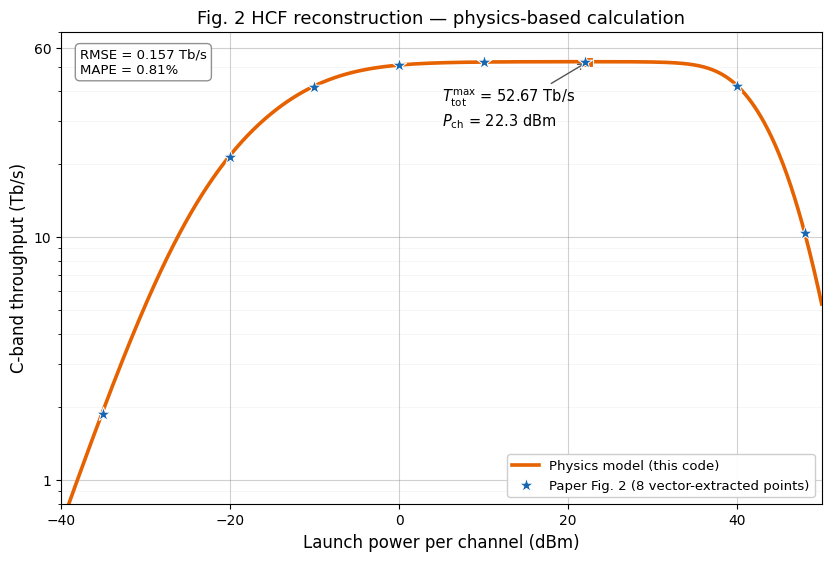

In [2]:
"""Physics-based reconstruction of the HCF curve in Fig. 2.

Target paper
------------
R. Sohanpal et al., "On the Optimum Energy-per-bit Launch Power in
Coherent Hollow-core Fibre Transmission Systems" (2026).

This script does not digitize Fig. 2 and does not contain a hand-entered
throughput curve.  For every launch power it computes, channel by channel,

    SNR_i = P_i / (P_ASE,i + eta_i P_i^3 + P_IMI,i + P_TRN,i)
    T_i   = 2 R log2(1 + SNR_i)

and sums T_i over the 29 C-band channels.  The wavelength-dependent HCF
attenuation and dispersion are supplied by the analytical DNANF model used
for the companion Fig. 1 notebook.

The exact Fig. 1 data in the paper came from a full-vector simulation and
unpublished fitting details.  The profile here is therefore a reproducible,
physics-calibrated approximation rather than the authors' original FEM data.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares


C0 = 299_792_458.0                 # vacuum speed of light [m/s]
H_PLANCK = 6.626_070_15e-34        # Planck constant [J s]
U01 = 2.4048255577                  # first zero of J0
DB_PER_NEPER = 10.0 / np.log(10.0)


# ---------------------------------------------------------------------------
# 1) Wavelength-dependent first-window DNANF attenuation and dispersion
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class DNANFGeometry:
    """Nominal first-window DNANF geometry from the companion Fig. 1 model."""

    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self) -> float:
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self) -> float:
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self) -> float:
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


def silica_index_sellmeier(wavelength_m: np.ndarray) -> np.ndarray:
    """Fused-silica refractive index from the three-term Sellmeier law."""
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi * wavelength_um_sq / (wavelength_um_sq - ci**2)
    return np.sqrt(n_sq)


def hasan_radius_coefficients(geometry: DNANFGeometry) -> tuple[float, float]:
    """Geometry-driven effective-radius coefficients (Hasan et al.)."""
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n
        + b3
        + 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    )
    return float(f1), float(f2)


def effective_index(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    """Fundamental-mode effective index from a modified capillary model."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    effective_radius = f1 * radius * (1.0 - f2 * wavelength_m**2 / (radius * wall))
    return 1.0 - 0.125 * (U01 * wavelength_m / (np.pi * effective_radius)) ** 2


def chromatic_dispersion_ps_nm_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
    derivative_step_nm: float = 0.20,
) -> np.ndarray:
    """Calculate D = -(lambda/c) d2(n_eff)/d(lambda)2 with a 5-point stencil."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    step = derivative_step_nm * 1e-9

    def n_eff(offset: float) -> np.ndarray:
        return effective_index(wavelength_m + offset, geometry, f1, f2)

    second_derivative = (
        -n_eff(2.0 * step)
        + 16.0 * n_eff(step)
        - 30.0 * n_eff(0.0)
        + 16.0 * n_eff(-step)
        - n_eff(-2.0 * step)
    ) / (12.0 * step**2)
    dispersion_si = -(wavelength_m / C0) * second_derivative  # [s/m^2]
    return dispersion_si / 1e-6  # [ps/(nm km)]


def calibrate_dispersion(geometry: DNANFGeometry) -> tuple[float, float]:
    """Calibrate the continuous dispersion model to the two stated paper values."""
    reference_nm = np.array([1310.0, 1550.0])
    reference_d = np.array([2.17, 3.20])
    initial = np.array(hasan_radius_coefficients(geometry))

    def residual(parameters: np.ndarray) -> np.ndarray:
        calculated = chromatic_dispersion_ps_nm_km(
            reference_nm * 1e-9, geometry, parameters[0], parameters[1]
        )
        return calculated - reference_d

    result = least_squares(
        residual,
        x0=initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac",
        diff_step=1e-3,
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
    )
    if not result.success or np.max(np.abs(result.fun)) > 1e-3:
        raise RuntimeError(f"Dispersion calibration failed: {result.fun}")
    return float(result.x[0]), float(result.x[1])


def capillary_bouncing_ray_loss_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    """Hybrid HE11 thin-wall bouncing-ray leakage (Bache et al.)."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall
    te_denominator = 4.0 * np.cos(phase) ** 2 + (
        kappa / sigma + sigma / kappa
    ) ** 2 * np.sin(phase) ** 2
    tm_denominator = 4.0 * np.cos(phase) ** 2 + (
        silica_n**2 * kappa / sigma + sigma / (silica_n**2 * kappa)
    ) ** 2 * np.sin(phase) ** 2
    alpha_te_per_m = 2.0 * U01 / (radius**2 * k0 * te_denominator)
    alpha_tm_per_m = 2.0 * U01 / (radius**2 * k0 * tm_denominator)
    return 0.5 * (alpha_te_per_m + alpha_tm_per_m) * DB_PER_NEPER * 1000.0


def attenuation_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    """Surface-scattering plus two-stage anti-resonant leakage model."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    reference_alpha = np.array([0.075, 0.120])
    lambda_ref_m = reference_nm[0] * 1e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm * 1e-9, geometry)
    basis_reference = np.column_stack(
        [
            (lambda_ref_m / (reference_nm * 1e-9)) ** 3,
            (br_ref / br_ref[0]) ** 2,
        ]
    )
    a_surface, a_nested = np.linalg.solve(basis_reference, reference_alpha)
    if a_surface < 0.0 or a_nested < 0.0:
        raise RuntimeError("Calibrated attenuation contributions must be non-negative.")
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    return (
        a_surface * (lambda_ref_m / wavelength_m) ** 3
        + a_nested * (br / br_ref[0]) ** 2
    )


# ---------------------------------------------------------------------------
# 2) C-band HCF transmission model used to calculate the Fig. 2 curve
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class HCFLink:
    """Parameters stated in the target paper for the Fig. 2 HCF case."""

    n_channels: int = 29
    symbol_rate_gbd: float = 140.0
    channel_spacing_ghz: float = 150.0
    c_band_min_nm: float = 1530.0
    c_band_max_nm: float = 1565.0
    span_length_km: float = 200.0
    n_spans: int = 1
    amplifier_noise_figure_db: float = 5.0
    transceiver_snr_db: float = 20.0
    nonlinear_coefficient_per_w_km: float = 5e-4
    imi_coefficient_db_per_km: float = -52.0

    @property
    def symbol_rate_hz(self) -> float:
        return self.symbol_rate_gbd * 1e9

    @property
    def channel_spacing_hz(self) -> float:
        return self.channel_spacing_ghz * 1e9

    @property
    def total_length_km(self) -> float:
        return self.n_spans * self.span_length_km


# Eight validation points extracted from the orange HCF vector path embedded
# in the paper PDF.  The PDF axes were calibrated from their vector gridlines:
# x is linear in dBm and y is logarithmic in Tb/s.  These values are displayed
# only for comparison and are never used by the physical transmission model.
PAPER_REFERENCE_LAUNCH_DBM = np.array(
    [-35.0, -20.0, -10.0, 0.0, 10.0, 22.0, 40.0, 48.0]
)
PAPER_REFERENCE_THROUGHPUT_TBPS = np.array(
    [
        1.87292462,
        21.32203450,
        41.62572367,
        50.95120740,
        52.49881133,
        52.67046429,
        42.03103403,
        10.44268748,
    ]
)


def c_band_channel_grid(link: HCFLink) -> tuple[np.ndarray, np.ndarray]:
    """Return 29 uniformly spaced C-band channel frequencies and wavelengths."""
    lower_frequency_hz = C0 / (link.c_band_max_nm * 1e-9)
    upper_frequency_hz = C0 / (link.c_band_min_nm * 1e-9)
    center_frequency_hz = 0.5 * (lower_frequency_hz + upper_frequency_hz)
    offsets = (np.arange(link.n_channels) - 0.5 * (link.n_channels - 1))
    frequency_hz = center_frequency_hz + offsets * link.channel_spacing_hz
    wavelength_m = C0 / frequency_hz
    if frequency_hz[0] < lower_frequency_hz or frequency_hz[-1] > upper_frequency_hz:
        raise ValueError("The selected channel grid does not fit inside the C-band.")
    return frequency_hz, wavelength_m


def dispersion_to_beta2_s2_per_km(
    dispersion_ps_nm_km: np.ndarray,
    wavelength_m: np.ndarray,
) -> np.ndarray:
    """Convert D [ps/(nm km)] to beta2 [s^2/km]."""
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6  # [s/m^2]
    beta2_s2_per_m = -(np.asarray(wavelength_m) ** 2 / (2.0 * np.pi * C0)) * dispersion_si
    return beta2_s2_per_m * 1000.0


def closed_form_gn_eta(
    beta2_s2_per_km: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    """Closed-form GN coefficient eta [1/W^2] from Poggiolini & Poletti.

    The paper defines 2*alpha as the power-loss coefficient.  Therefore the
    field-loss coefficient used in this equation is alpha_dB / 8.685889638.
    All length quantities are consistently expressed per kilometre.
    """
    beta2 = np.abs(np.asarray(beta2_s2_per_km, dtype=float))
    alpha_field_per_km = np.asarray(attenuation_db_per_km) / 8.685889638
    gamma = link.nonlinear_coefficient_per_w_km
    rate = link.symbol_rate_hz
    spacing = link.channel_spacing_hz
    asinh_argument = (
        np.pi**2
        * beta2
        * rate**2
        / (4.0 * alpha_field_per_km)
        * link.n_channels ** (2.0 * rate / spacing)
    )
    return (
        link.n_spans
        * 4.0
        * gamma**2
        / (27.0 * np.pi * beta2 * alpha_field_per_km * rate**2)
        * np.arcsinh(asinh_argument)
    )


def per_channel_ase_w(
    frequency_hz: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    link: HCFLink,
) -> np.ndarray:
    """Accumulated dual-polarisation ASE in the matched bandwidth R."""
    span_gain = 10.0 ** (
        np.asarray(attenuation_db_per_km) * link.span_length_km / 10.0
    )
    noise_factor = 10.0 ** (link.amplifier_noise_figure_db / 10.0)
    return (
        link.n_spans
        * H_PLANCK
        * np.asarray(frequency_hz)
        * noise_factor
        * link.symbol_rate_hz
        * (span_gain - 1.0)
    )


def simulate_hcf_throughput(
    link: HCFLink,
    launch_dbm: np.ndarray,
) -> dict[str, np.ndarray | float]:
    """Calculate SNR and total throughput for every requested launch power."""
    launch_dbm = np.asarray(launch_dbm, dtype=float)
    geometry = DNANFGeometry()
    f1, f2 = calibrate_dispersion(geometry)
    frequency_hz, wavelength_m = c_band_channel_grid(link)
    dispersion = chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2)
    attenuation = attenuation_db_km(wavelength_m, geometry)
    beta2 = dispersion_to_beta2_s2_per_km(dispersion, wavelength_m)
    eta = closed_form_gn_eta(beta2, attenuation, link)
    ase_w = per_channel_ase_w(frequency_hz, attenuation, link)

    launch_w = 10.0 ** ((launch_dbm - 30.0) / 10.0)
    signal = launch_w[:, None]
    ase = ase_w[None, :]
    nonlinear = eta[None, :] * signal**3
    imi_ratio_per_km = 10.0 ** (link.imi_coefficient_db_per_km / 10.0)
    imi = signal * imi_ratio_per_km * link.total_length_km
    transceiver = signal / (10.0 ** (link.transceiver_snr_db / 10.0))
    snr = signal / (ase + nonlinear + imi + transceiver)
    throughput_per_channel_bps = 2.0 * link.symbol_rate_hz * np.log2(1.0 + snr)
    total_throughput_tbps = throughput_per_channel_bps.sum(axis=1) / 1e12
    optimum_index = int(np.argmax(total_throughput_tbps))

    if not np.all(np.isfinite(total_throughput_tbps)) or np.any(total_throughput_tbps <= 0.0):
        raise RuntimeError("The calculated throughput contains invalid values.")

    return {
        "launch_dbm": launch_dbm,
        "launch_w": launch_w,
        "frequency_hz": frequency_hz,
        "wavelength_m": wavelength_m,
        "attenuation_db_km": attenuation,
        "dispersion_ps_nm_km": dispersion,
        "beta2_s2_km": beta2,
        "eta_per_w2": eta,
        "ase_w": ase_w,
        "snr_linear": snr,
        "throughput_per_channel_bps": throughput_per_channel_bps,
        "total_throughput_tbps": total_throughput_tbps,
        "optimum_index": optimum_index,
        "optimum_launch_dbm": float(launch_dbm[optimum_index]),
        "maximum_throughput_tbps": float(total_throughput_tbps[optimum_index]),
    }


def compare_with_paper(
    result: dict[str, np.ndarray | float],
) -> dict[str, np.ndarray | float]:
    """Compare the calculation with eight vector-extracted Fig. 2 points."""
    model_at_reference = np.interp(
        PAPER_REFERENCE_LAUNCH_DBM,
        np.asarray(result["launch_dbm"]),
        np.asarray(result["total_throughput_tbps"]),
    )
    error_tbps = model_at_reference - PAPER_REFERENCE_THROUGHPUT_TBPS
    relative_error_percent = 100.0 * error_tbps / PAPER_REFERENCE_THROUGHPUT_TBPS
    return {
        "launch_dbm": PAPER_REFERENCE_LAUNCH_DBM.copy(),
        "paper_tbps": PAPER_REFERENCE_THROUGHPUT_TBPS.copy(),
        "model_tbps": model_at_reference,
        "error_tbps": error_tbps,
        "relative_error_percent": relative_error_percent,
        "rmse_tbps": float(np.sqrt(np.mean(error_tbps**2))),
        "mape_percent": float(np.mean(np.abs(relative_error_percent))),
        "maximum_absolute_relative_error_percent": float(
            np.max(np.abs(relative_error_percent))
        ),
    }


def plot_hcf_curve(
    result: dict[str, np.ndarray | float],
    output_path: Path | str = Path("fig2_hcf_colab.png"),
) -> plt.Figure:
    """Plot only the orange HCF curve using the axes of the paper's Fig. 2."""
    launch_dbm = np.asarray(result["launch_dbm"])
    throughput = np.asarray(result["total_throughput_tbps"])
    optimum_index = int(result["optimum_index"])
    comparison = compare_with_paper(result)

    fig, ax = plt.subplots(figsize=(8.2, 5.5), constrained_layout=True)
    ax.plot(
        launch_dbm,
        throughput,
        color="#e66100",
        lw=2.6,
        label="Physics model (this code)",
    )
    ax.plot(
        launch_dbm[optimum_index],
        throughput[optimum_index],
        marker="s",
        ms=7,
        color="#e66100",
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=5,
    )
    ax.scatter(
        comparison["launch_dbm"],
        comparison["paper_tbps"],
        marker="*",
        s=115,
        color="#1666b1",
        edgecolors="white",
        linewidths=0.7,
        label="Paper Fig. 2 (8 vector-extracted points)",
        zorder=6,
    )
    ax.annotate(
        rf"$T_{{\rm tot}}^{{\max}}$ = {throughput[optimum_index]:.2f} Tb/s"
        "\n"
        rf"$P_{{\rm ch}}$ = {launch_dbm[optimum_index]:.1f} dBm",
        xy=(launch_dbm[optimum_index], throughput[optimum_index]),
        xytext=(-105, -46),
        textcoords="offset points",
        fontsize=10.5,
        arrowprops={"arrowstyle": "->", "color": "#555555", "lw": 1.0},
    )
    ax.set_yscale("log")
    ax.set_xlim(-40.0, 50.0)
    ax.set_ylim(0.8, 70.0)
    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([1, 10, 60], labels=["1", "10", "60"])
    ax.set_xlabel("Launch power per channel (dBm)", fontsize=12)
    ax.set_ylabel("C-band throughput (Tb/s)", fontsize=12)
    ax.set_title("Fig. 2 HCF reconstruction — physics-based calculation", fontsize=13)
    ax.grid(True, which="major", color="#8a8a8a", alpha=0.40, linewidth=0.8)
    ax.grid(True, which="minor", axis="y", color="#b5b5b5", alpha=0.16, linewidth=0.5)
    ax.text(
        0.025,
        0.965,
        f"RMSE = {comparison['rmse_tbps']:.3f} Tb/s\n"
        f"MAPE = {comparison['mape_percent']:.2f}%",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9.5,
        bbox={"boxstyle": "round,pad=0.35", "fc": "white", "ec": "#888888", "alpha": 0.92},
    )
    ax.legend(loc="lower right", frameon=True, framealpha=0.95, fontsize=9.5)
    output_path = Path(output_path)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return fig


def print_summary(result: dict[str, np.ndarray | float], link: HCFLink) -> None:
    """Print the main model outputs and basic reproduction checks."""
    wavelength_nm = np.asarray(result["wavelength_m"]) * 1e9
    attenuation = np.asarray(result["attenuation_db_km"])
    dispersion = np.asarray(result["dispersion_ps_nm_km"])
    eta = np.asarray(result["eta_per_w2"])
    ase_w = np.asarray(result["ase_w"])
    optimum_launch_dbm = float(result["optimum_launch_dbm"])
    maximum_throughput_tbps = float(result["maximum_throughput_tbps"])

    print("=== Fig. 2 HCF calculation ===")
    print(f"Channels / baud rate / spacing : {link.n_channels} / {link.symbol_rate_gbd:.0f} GBd / {link.channel_spacing_ghz:.0f} GHz")
    print(f"C-band channel wavelengths     : {wavelength_nm.min():.2f}–{wavelength_nm.max():.2f} nm")
    print(f"HCF attenuation across grid    : {attenuation.min():.4f}–{attenuation.max():.4f} dB/km")
    print(f"HCF dispersion across grid     : {dispersion.min():.4f}–{dispersion.max():.4f} ps/(nm·km)")
    print(f"GN eta across grid             : {eta.min():.3e}–{eta.max():.3e} 1/W²")
    print(f"ASE per channel                : {10.0 * np.log10(ase_w.mean()) + 30.0:.2f} dBm (mean)")
    print(f"Maximum throughput             : {maximum_throughput_tbps:.3f} Tb/s")
    print(f"Launch power at maximum        : {optimum_launch_dbm:.2f} dBm/channel")

    comparison = compare_with_paper(result)
    print("\n=== Comparison with paper's vector curve ===")
    print(" Pch (dBm) | Paper (Tb/s) | Model (Tb/s) | Error (%)")
    print("------------+--------------+--------------+----------")
    for launch, paper, model, error_percent in zip(
        comparison["launch_dbm"],
        comparison["paper_tbps"],
        comparison["model_tbps"],
        comparison["relative_error_percent"],
    ):
        print(f" {launch:10.1f} | {paper:12.4f} | {model:12.4f} | {error_percent:+8.3f}")
    print(f"RMSE                            : {comparison['rmse_tbps']:.4f} Tb/s")
    print(f"Mean absolute percentage error  : {comparison['mape_percent']:.3f}%")
    print(
        "Maximum absolute relative error: "
        f"{comparison['maximum_absolute_relative_error_percent']:.3f}%"
    )

    # Expected ranges are broad physical/reproduction checks, not curve inputs.
    assert 50.0 < maximum_throughput_tbps < 55.0
    assert 15.0 < optimum_launch_dbm < 30.0
    print("Validation: PASS (finite curve and expected Fig. 2 HCF range)")


def main() -> tuple[dict[str, np.ndarray | float], plt.Figure]:
    link = HCFLink()
    launch_dbm = np.linspace(-40.0, 50.0, 1201)
    result = simulate_hcf_throughput(link, launch_dbm)
    figure = plot_hcf_curve(result, Path("fig2_hcf_colab.png"))
    print_summary(result, link)
    plt.show()
    return result, figure


if __name__ == "__main__":
    result, figure = main()


## HCF–G.654.E–SMF 해저구간 비교

이 셀은 동일한 29채널·140 GBd·150 GHz 간격, 증폭기 NF 5 dB, 송수신기 SNR 20 dB 조건에서 다음 광섬유를 비교합니다.

| 광섬유 | 감쇠 @1550 nm | 분산 @1550 nm | MFD | Aeff | 분산기울기 | n2 | γ |
|---|---:|---:|---:|---:|---:|---:|---:|
| TeraWave_SCUBA G.654.E | 0.151 dB/km | 22 ps/(nm·km) | 11.5 µm | 110 µm² | 0.06 ps/(nm²·km) | 2.2×10⁻²⁰ m²/W | 0.81 W⁻¹km⁻¹ |
| Corning SMF-28 ULL | 0.156 dB/km | 18 ps/(nm·km) | 10.5 µm | 82 µm² | 0.06 ps/(nm²·km) | 2.6×10⁻²⁰ m²/W | 1.29 W⁻¹km⁻¹ |
| HCF | 앞 셀의 DNANF 파장 의존 모델 | 앞 셀의 DNANF 파장 의존 모델 | — | — | — | — | 5×10⁻⁴ W⁻¹km⁻¹ |

- 실리카 광섬유의 C-band 감쇠는 입력된 1550 nm 값을 일정하게 적용하고, 분산은 D(λ)=D1550+S(λ−1550)으로 계산합니다.
- γ 입력값은 γ=2πn2/(λAeff)로 다시 계산해 2% 이내인지 검사합니다.
- 실리카 단일코어 광섬유의 IMI는 0이며, HCF만 −52 dB/km를 적용합니다.
- 각 광섬유와 repeater 수마다 채널 launch power를 독립적으로 스윕하여 최대 용량을 사용합니다.
- 해저 submerged repeater 수는 Nrep=Nspan−1로 정의합니다.
- 기본 분석점은 1,000 km, 40 Tb/s이며 셀 하단의 `ROUTE_LENGTH_KM`, `TARGET_CAPACITY_TBPS`, `MAX_REPEATERS`로 변경할 수 있습니다.

출력 그래프는 (1) 목표 용량별 최소 repeater 수와 (2) 동일 구간·동일 repeater 수에서의 최대 용량을 보여줍니다. 결과 딕셔너리에는 HCF의 repeater 절감량과 G.654.E 대비 용량 증가량·증가율이 저장됩니다.

> 주의: 이 비교는 기존 노트북과 같은 ASE+closed-form GN+IMI+송수신기 잡음 모델입니다. 증폭기 최대 이득·출력, 최대 허용 span loss, 케이블/접속 margin은 제한하지 않으므로 시스템 설계 확정값이 아니라 이론 비교값입니다.


=== Submarine comparison summary ===
Route / target: 1000 km / 40.00 Tb/s
TeraWave_SCUBA G.654.E: specified gamma=0.810, n2/Aeff-derived gamma=0.811 W^-1 km^-1
Corning SMF-28 ULL: specified gamma=1.290, n2/Aeff-derived gamma=1.285 W^-1 km^-1
Fiber                         Repeaters  Span (km)  Capacity  Popt
HCF (DNANF analytical model)          1     500.00    47.722  29.90
TeraWave_SCUBA G.654.E                6     142.86    42.293   6.80
Corning SMF-28 ULL                    7     125.00    40.996   4.50
HCF repeater reduction vs G.654.E: 5 (83.33%)
Equal-condition repeater count: 6
HCF (DNANF analytical model)  capacity=  48.369 Tb/s, Popt= 20.80 dBm/ch, span= 142.86 km
TeraWave_SCUBA G.654.E        capacity=  42.293 Tb/s, Popt=  6.80 dBm/ch, span= 142.86 km
Corning SMF-28 ULL            capacity=  38.603 Tb/s, Popt=  5.50 dBm/ch, span= 142.86 km
HCF capacity gain vs G.654.E: +6.077 Tb/s (+14.37%)


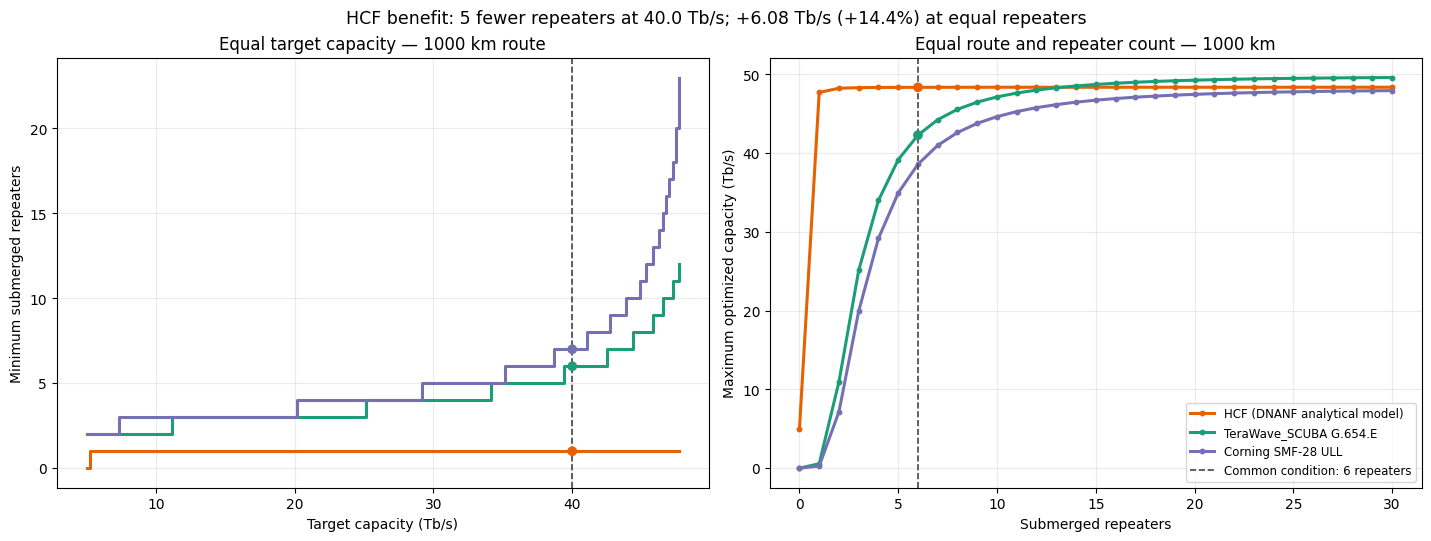

In [3]:
from dataclasses import dataclass, replace

@dataclass(frozen=True)
class FiberSpec:
    label: str
    short_label: str
    color: str
    model: str
    attenuation_1550_db_km: float | None
    dispersion_1550_ps_nm_km: float | None
    dispersion_slope_ps_nm2_km: float | None
    mfd_um: float | None
    effective_area_um2: float | None
    n2_m2_w: float | None
    gamma_w_inv_km_inv: float
    imi_db_per_km: float | None = None


FIBERS = {
    "HCF": FiberSpec(
        label="HCF (DNANF analytical model)",
        short_label="HCF",
        color="#e66100",
        model="dnanf",
        attenuation_1550_db_km=None,
        dispersion_1550_ps_nm_km=None,
        dispersion_slope_ps_nm2_km=None,
        mfd_um=None,
        effective_area_um2=None,
        n2_m2_w=None,
        gamma_w_inv_km_inv=5.0e-4,
        imi_db_per_km=-52.0,
    ),
    "G654E": FiberSpec(
        label="TeraWave_SCUBA G.654.E",
        short_label="G.654.E",
        color="#1b9e77",
        model="solid_core",
        attenuation_1550_db_km=0.151,
        dispersion_1550_ps_nm_km=22.0,
        dispersion_slope_ps_nm2_km=0.060,
        mfd_um=11.5,
        effective_area_um2=110.0,
        n2_m2_w=2.2e-20,
        gamma_w_inv_km_inv=0.81,
    ),
    "SMF": FiberSpec(
        label="Corning SMF-28 ULL",
        short_label="SMF-28 ULL",
        color="#7570b3",
        model="solid_core",
        attenuation_1550_db_km=0.156,
        dispersion_1550_ps_nm_km=18.0,
        dispersion_slope_ps_nm2_km=0.060,
        mfd_um=10.5,
        effective_area_um2=82.0,
        n2_m2_w=2.6e-20,
        gamma_w_inv_km_inv=1.29,
    ),
}


def gamma_from_n2_aeff(n2_m2_w: float, aeff_um2: float, wavelength_nm=1550.0):
    """Return gamma in W^-1 km^-1 from n2 and effective area."""
    return (
        2.0
        * np.pi
        * n2_m2_w
        / (wavelength_nm * 1e-9 * aeff_um2 * 1e-12)
        * 1e3
    )


def fiber_profiles(fiber: FiberSpec, wavelength_m: np.ndarray):
    if fiber.model == "dnanf":
        geometry = DNANFGeometry()
        f1, f2 = calibrate_dispersion(geometry)
        attenuation = attenuation_db_km(wavelength_m, geometry)
        dispersion = chromatic_dispersion_ps_nm_km(
            wavelength_m, geometry, f1, f2
        )
    else:
        wavelength_nm = np.asarray(wavelength_m) * 1e9
        attenuation = np.full_like(
            wavelength_nm, fiber.attenuation_1550_db_km, dtype=float
        )
        dispersion = (
            fiber.dispersion_1550_ps_nm_km
            + fiber.dispersion_slope_ps_nm2_km * (wavelength_nm - 1550.0)
        )
    return attenuation, dispersion


def simulate_fiber_route(
    fiber: FiberSpec,
    route_length_km: float,
    repeater_count: int,
    launch_dbm: np.ndarray,
    base_link: HCFLink | None = None,
):
    if route_length_km <= 0:
        raise ValueError("route_length_km must be positive")
    if repeater_count < 0:
        raise ValueError("repeater_count must be non-negative")
    base_link = HCFLink() if base_link is None else base_link
    n_spans = int(repeater_count) + 1
    link = replace(
        base_link,
        n_spans=n_spans,
        span_length_km=route_length_km / n_spans,
        nonlinear_coefficient_per_w_km=fiber.gamma_w_inv_km_inv,
        imi_coefficient_db_per_km=(
            fiber.imi_db_per_km if fiber.imi_db_per_km is not None else -np.inf
        ),
    )
    frequency_hz, wavelength_m = c_band_channel_grid(link)
    attenuation, dispersion = fiber_profiles(fiber, wavelength_m)
    beta2 = dispersion_to_beta2_s2_per_km(dispersion, wavelength_m)
    eta = closed_form_gn_eta(beta2, attenuation, link)
    ase_w = per_channel_ase_w(frequency_hz, attenuation, link)

    launch_dbm = np.asarray(launch_dbm, dtype=float)
    launch_w = 10.0 ** ((launch_dbm - 30.0) / 10.0)
    signal = launch_w[:, None]
    nonlinear = eta[None, :] * signal**3
    if fiber.imi_db_per_km is None:
        imi = np.zeros_like(signal)
    else:
        imi = (
            signal
            * 10.0 ** (fiber.imi_db_per_km / 10.0)
            * route_length_km
        )
    transceiver = signal / 10.0 ** (link.transceiver_snr_db / 10.0)
    snr = signal / (ase_w[None, :] + nonlinear + imi + transceiver)
    capacity_tbps = (
        2.0 * link.symbol_rate_hz * np.log2(1.0 + snr)
    ).sum(axis=1) / 1e12
    optimum_index = int(np.argmax(capacity_tbps))
    return {
        "fiber": fiber,
        "route_length_km": float(route_length_km),
        "repeater_count": int(repeater_count),
        "n_spans": n_spans,
        "span_length_km": float(link.span_length_km),
        "launch_dbm": launch_dbm,
        "capacity_tbps": capacity_tbps,
        "optimum_launch_dbm": float(launch_dbm[optimum_index]),
        "maximum_capacity_tbps": float(capacity_tbps[optimum_index]),
    }


def capacity_repeater_sweep(
    route_length_km: float,
    max_repeaters: int,
    launch_dbm: np.ndarray,
):
    repeaters = np.arange(max_repeaters + 1, dtype=int)
    results = {}
    for key, fiber in FIBERS.items():
        simulations = [
            simulate_fiber_route(fiber, route_length_km, int(n), launch_dbm)
            for n in repeaters
        ]
        results[key] = {
            "simulations": simulations,
            "capacity_tbps": np.array(
                [item["maximum_capacity_tbps"] for item in simulations]
            ),
            "optimum_launch_dbm": np.array(
                [item["optimum_launch_dbm"] for item in simulations]
            ),
        }
    return repeaters, results


def first_repeater_for_target(capacity_tbps, repeaters, target_tbps):
    indices = np.flatnonzero(np.asarray(capacity_tbps) >= target_tbps)
    return None if len(indices) == 0 else int(repeaters[indices[0]])


def lookup_at_repeater(sweep, repeater_count):
    item = sweep["simulations"][int(repeater_count)]
    return item["maximum_capacity_tbps"], item["optimum_launch_dbm"], item["span_length_km"]


def run_submarine_comparison(
    route_length_km=1000.0,
    target_capacity_tbps=40.0,
    max_repeaters=30,
):
    launch_dbm = np.linspace(-20.0, 30.0, 501)
    repeaters, sweeps = capacity_repeater_sweep(
        route_length_km, max_repeaters, launch_dbm
    )

    required = {
        key: first_repeater_for_target(
            value["capacity_tbps"], repeaters, target_capacity_tbps
        )
        for key, value in sweeps.items()
    }
    if required["G654E"] is None or required["HCF"] is None:
        raise RuntimeError("Increase max_repeaters or select a reachable target capacity.")

    g654e_repeaters = required["G654E"]
    hcf_repeaters = required["HCF"]
    repeater_reduction = g654e_repeaters - hcf_repeaters
    repeater_reduction_percent = (
        np.nan
        if g654e_repeaters == 0
        else 100.0 * repeater_reduction / g654e_repeaters
    )

    common_repeaters = g654e_repeaters
    common = {
        key: lookup_at_repeater(value, common_repeaters)
        for key, value in sweeps.items()
    }
    hcf_capacity = common["HCF"][0]
    g654e_capacity = common["G654E"][0]
    capacity_gain_tbps = hcf_capacity - g654e_capacity
    capacity_gain_percent = 100.0 * capacity_gain_tbps / g654e_capacity

    common_ceiling = min(value["capacity_tbps"].max() for value in sweeps.values())
    target_grid = np.linspace(5.0, max(5.0, common_ceiling - 0.25), 181)

    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.3), constrained_layout=True)
    for key, fiber in FIBERS.items():
        needed = np.array([
            first_repeater_for_target(sweeps[key]["capacity_tbps"], repeaters, target)
            for target in target_grid
        ], dtype=float)
        axes[0].step(target_grid, needed, where="post", lw=2.2,
                     color=fiber.color, label=fiber.label)
        axes[1].plot(repeaters, sweeps[key]["capacity_tbps"], lw=2.2,
                     marker="o", ms=3.2, color=fiber.color, label=fiber.label)

    axes[0].axvline(target_capacity_tbps, color="#444444", ls="--", lw=1.2)
    reached_keys = [key for key in FIBERS if required[key] is not None]
    axes[0].scatter(
        [target_capacity_tbps] * len(reached_keys),
        [required[key] for key in reached_keys],
        color=[FIBERS[key].color for key in reached_keys],
        zorder=5,
    )
    axes[0].set_xlabel("Target capacity (Tb/s)")
    axes[0].set_ylabel("Minimum submerged repeaters")
    axes[0].set_title(f"Equal target capacity — {route_length_km:.0f} km route")
    axes[0].grid(True, alpha=0.25)

    axes[1].axvline(common_repeaters, color="#444444", ls="--", lw=1.2,
                    label=f"Common condition: {common_repeaters} repeaters")
    axes[1].scatter([common_repeaters, common_repeaters],
                    [hcf_capacity, g654e_capacity],
                    color=[FIBERS["HCF"].color, FIBERS["G654E"].color], zorder=5)
    axes[1].set_xlabel("Submerged repeaters")
    axes[1].set_ylabel("Maximum optimized capacity (Tb/s)")
    axes[1].set_title(f"Equal route and repeater count — {route_length_km:.0f} km")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(fontsize=8.5)

    fig.suptitle(
        f"HCF benefit: {repeater_reduction} fewer repeaters at {target_capacity_tbps:.1f} Tb/s; "
        f"{capacity_gain_tbps:+.2f} Tb/s ({capacity_gain_percent:+.1f}%) at equal repeaters",
        fontsize=12.5,
    )
    fig.savefig("hcf_g654e_smf_submarine_comparison.png", dpi=220, bbox_inches="tight")

    print("=== Submarine comparison summary ===")
    print(f"Route / target: {route_length_km:.0f} km / {target_capacity_tbps:.2f} Tb/s")
    for key in ("G654E", "SMF"):
        fiber = FIBERS[key]
        derived_gamma = gamma_from_n2_aeff(
            fiber.n2_m2_w, fiber.effective_area_um2
        )
        if not np.isclose(derived_gamma, fiber.gamma_w_inv_km_inv, rtol=0.02):
            raise RuntimeError(f"{fiber.label}: gamma is inconsistent with n2 and Aeff")
        print(
            f"{fiber.label}: specified gamma={fiber.gamma_w_inv_km_inv:.3f}, "
            f"n2/Aeff-derived gamma={derived_gamma:.3f} W^-1 km^-1"
        )
    print("Fiber                         Repeaters  Span (km)  Capacity  Popt")
    for key, fiber in FIBERS.items():
        nrep = required[key]
        if nrep is None:
            print(f"{fiber.label:29s}   not reached")
            continue
        cap, popt, span = lookup_at_repeater(sweeps[key], nrep)
        print(f"{fiber.label:29s} {nrep:9d} {span:10.2f} {cap:9.3f} {popt:6.2f}")
    print(f"HCF repeater reduction vs G.654.E: {repeater_reduction:d} "
          f"({repeater_reduction_percent:.2f}%)")
    print(f"Equal-condition repeater count: {common_repeaters:d}")
    for key, fiber in FIBERS.items():
        cap, popt, span = common[key]
        print(f"{fiber.label:29s} capacity={cap:8.3f} Tb/s, "
              f"Popt={popt:6.2f} dBm/ch, span={span:7.2f} km")
    print(f"HCF capacity gain vs G.654.E: {capacity_gain_tbps:+.3f} Tb/s "
          f"({capacity_gain_percent:+.2f}%)")

    return {
        "repeaters": repeaters,
        "sweeps": sweeps,
        "required_repeaters": required,
        "repeater_reduction": repeater_reduction,
        "repeater_reduction_percent": repeater_reduction_percent,
        "common_repeater_count": common_repeaters,
        "equal_condition": common,
        "capacity_gain_tbps": capacity_gain_tbps,
        "capacity_gain_percent": capacity_gain_percent,
        "figure": fig,
    }

# Editable comparison inputs
ROUTE_LENGTH_KM = 1000.0
TARGET_CAPACITY_TBPS = 40.0
MAX_REPEATERS = 30

comparison = run_submarine_comparison(
    route_length_km=ROUTE_LENGTH_KM,
    target_capacity_tbps=TARGET_CAPACITY_TBPS,
    max_repeaters=MAX_REPEATERS,
)
plt.show()


## Telecom Italia Field Trial: 재현 범위와 기준값

첨부 논문 `tesi(20260826-170200).pdf`의 Chapter 6.1, Tables 6.1-6.3, Figure 6.2와 Appendix의 `TIM` 설정을 사용한다.

- Field-trial 구조: Torino-Chivasso loop-back, 약 80 km 광경로
- 계산 구현값: 30 WDM channels(14 + CUT + 15), 193.4 THz, 76.5 km/span, NF 6.5 dB, EDFA gain 24.174 dB
- 논문 광섬유: α=0.3 dB/km, β₂=-21 ps²/km, γ=1.21 W⁻¹km⁻¹
- Figure 6.2 GN/GGN 기준 최적점: DP-4QAM 4 dBm·12 spans, DP-8QAM 3 dBm·13 spans, DP-16QAM 2 dBm·9 spans

본문의 실제 field-trial 설명은 최적 입력을 `DP-4QAM >5 dBm`, `DP-8QAM≈3 dBm`, `DP-16QAM≈3 dBm`으로 기술한다. 아래 정밀도 표는 실험 측정값이 아니라 **Figure 6.2의 GN/GGN 시뮬레이션값**과 비교한다.


In [4]:
from scipy.optimize import brentq
import pandas as pd
from IPython.display import display, Markdown


TIM_CENTER_FREQUENCY_HZ = 193.4e12
TIM_CENTER_WAVELENGTH_M = C0 / TIM_CENTER_FREQUENCY_HZ
TIM_SPAN_LENGTH_KM = 76.5
TIM_NOISE_FIGURE_DB = 6.5
TIM_REFERENCE_GAIN_DB = 24.174
TIM_REFERENCE_ALPHA_DB_KM = 0.3
TIM_LUMPED_LOSS_DB = (
    TIM_REFERENCE_GAIN_DB - TIM_REFERENCE_ALPHA_DB_KM * TIM_SPAN_LENGTH_KM
)
TIM_N_CHANNELS = 30
TIM_CUT_INDEX = 14                  # 14 channels below CUT, 15 above CUT
TIM_NLI_COHERENCE_EXPONENT = 0.05  # inherited from the user's GN/GDF notebook
TIM_MAX_SPANS = 200


@dataclass(frozen=True)
class TIMModulation:
    label: str
    baud_rate_gbd: float
    spacing_ghz: float
    fec_ber: float
    snr_sensitivity_db: float
    osnr_sensitivity_db: float
    spectral_efficiency: float
    fec_overhead_percent: float
    paper_optimum_dbm: float
    paper_max_spans: int


TIM_MODULATIONS = {
    "DP-4QAM": TIMModulation(
        "DP-4QAM (DP-QPSK)", 57.24, 68.75, 1.0e-2, 12.39, 19.0,
        2.9, 7.0, 4.0, 12,
    ),
    "DP-8QAM": TIMModulation(
        "DP-8QAM", 42.0, 50.0, 2.4e-2, 12.13, 17.4,
        3.9, 15.0, 3.0, 13,
    ),
    "DP-16QAM": TIMModulation(
        "DP-16QAM", 33.01, 37.5, 3.4e-2, 13.77, 18.0,
        5.5, 20.0, 2.0, 9,
    ),
}


@dataclass(frozen=True)
class TIMFiber:
    label: str
    alpha_db_km: float
    beta2_ps2_km: float
    gamma_w_inv_km: float
    color: str
    imi_db_km: float | None = None
    mfd_um: float | None = None
    aeff_um2: float | None = None
    n2_m2_w: float | None = None


def D_to_beta2_ps2_km(D_ps_nm_km: float, wavelength_m=TIM_CENTER_WAVELENGTH_M):
    beta2_s2_km = dispersion_to_beta2_s2_per_km(
        np.array([D_ps_nm_km], dtype=float), np.array([wavelength_m], dtype=float)
    )[0]
    return float(beta2_s2_km * 1e24)


# HCF centre-frequency parameters are generated by the same DNANF model used above.
_tim_geometry = DNANFGeometry()
_tim_f1, _tim_f2 = calibrate_dispersion(_tim_geometry)
_tim_wavelength = np.array([TIM_CENTER_WAVELENGTH_M])
_tim_hcf_alpha = float(attenuation_db_km(_tim_wavelength, _tim_geometry)[0])
_tim_hcf_D = float(
    chromatic_dispersion_ps_nm_km(
        _tim_wavelength, _tim_geometry, _tim_f1, _tim_f2
    )[0]
)


TIM_FIBERS = {
    "Paper": TIMFiber(
        "Telecom Italia trial fibre (Table 6.2)", 0.3, -21.0, 1.21, "#4d4d4d"
    ),
    "G654E": TIMFiber(
        "TeraWave_SCUBA G.654.E", 0.151,
        D_to_beta2_ps2_km(22.0), 0.81, "#1b9e77",
        mfd_um=11.5, aeff_um2=110.0, n2_m2_w=2.2e-20,
    ),
    "SMF": TIMFiber(
        "Corning SMF-28 ULL", 0.156,
        D_to_beta2_ps2_km(18.0), 1.29, "#7570b3",
        mfd_um=10.5, aeff_um2=82.0, n2_m2_w=2.6e-20,
    ),
    "HCF": TIMFiber(
        "HCF (DNANF analytical model)", _tim_hcf_alpha,
        D_to_beta2_ps2_km(_tim_hcf_D), 5.0e-4, "#e66100",
        imi_db_km=-52.0,
    ),
}


tim_modulation_table = pd.DataFrame([
    {
        "Format": item.label,
        "Rs [GBd]": item.baud_rate_gbd,
        "Spacing [GHz]": item.spacing_ghz,
        "FEC BER": item.fec_ber,
        "SNRsens [dB]": item.snr_sensitivity_db,
        "Paper Popt [dBm/ch]": item.paper_optimum_dbm,
        "Paper max reach [km]": item.paper_max_spans * TIM_SPAN_LENGTH_KM,
    }
    for item in TIM_MODULATIONS.values()
])

tim_fiber_table = pd.DataFrame([
    {
        "Fiber": fiber.label,
        "alpha [dB/km]": fiber.alpha_db_km,
        "beta2 [ps^2/km]": fiber.beta2_ps2_km,
        "gamma [1/W/km]": fiber.gamma_w_inv_km,
        "MFD [um]": fiber.mfd_um,
        "Aeff [um^2]": fiber.aeff_um2,
        "n2 [m^2/W]": fiber.n2_m2_w,
        "IMI [dB/km]": fiber.imi_db_km,
    }
    for fiber in TIM_FIBERS.values()
])

display(tim_modulation_table)
display(tim_fiber_table)
print(
    f"TIM common condition: Nch={TIM_N_CHANNELS}, fCUT={TIM_CENTER_FREQUENCY_HZ/1e12:.1f} THz, "
    f"Lspan={TIM_SPAN_LENGTH_KM:.1f} km, NF={TIM_NOISE_FIGURE_DB:.1f} dB, "
    f"lumped loss={TIM_LUMPED_LOSS_DB:.3f} dB"
)


,Format,Rs [GBd],Spacing [GHz],FEC BER,SNRsens [dB],Paper Popt [dBm/ch],Paper max reach [km]
0,DP-4QAM (DP-QPSK),57.24,68.75,0.010,12.39,4.0,918.0
1,DP-8QAM,42.00,50.00,0.024,12.13,3.0,994.5
2,DP-16QAM,33.01,37.50,0.034,13.77,2.0,688.5


,Fiber,alpha [dB/km],beta2 [ps^2/km],gamma [1/W/km],MFD [um],Aeff [um^2],n2 [m^2/W],IMI [dB/km]
0,Telecom Italia trial fibre (Table 6.2),0.300000,-21.000000,1.2100,NaN,NaN,NaN,NaN
1,TeraWave_SCUBA G.654.E,0.151000,-28.064065,0.8100,11.5,110.0,2.200000e-20,NaN
2,Corning SMF-28 ULL,0.156000,-22.961508,1.2900,10.5,82.0,2.600000e-20,NaN
3,HCF (DNANF analytical model),0.074994,-4.082808,0.0005,NaN,NaN,NaN,-52.0


TIM common condition: Nch=30, fCUT=193.4 THz, Lspan=76.5 km, NF=6.5 dB, lumped loss=1.224 dB


## 사용자 GN 모델의 Telecom Italia 조건 이식

아래 함수는 기존 교차검증 노트북의 rectangular-WDM Cartesian GN 적분을 그대로 사용한다. 단일-span 수치 적분으로 η를 구하고, 기존 해저 GN/GDF 코드의 다중-span 누적식 η<sub>N</sub>=η<sub>1</sub>N<sup>1+ε</sup>(ε=0.05)을 적용한다. 논문의 exact coherent multi-span GN 적분과는 동일하지 않으므로, 그 차이는 숨기지 않고 오차로 표시한다.

수신기 구현 페널티는 Table 6.3의 `SNRsens`에 이미 포함된 것으로 보고 별도 TRX 잡음을 더하지 않는다. HCF만 기존 코드와 동일하게 IMI -52 dB/km를 포함한다.


In [5]:
def tim_rectangular_wdm_psd(
    frequency_hz: np.ndarray,
    centers_hz: np.ndarray,
    channel_bandwidth_hz: float,
    pch_w: float = 1.0,
):
    """Normalized rectangular WDM PSD used by the user's numerical GN code."""
    frequency_hz = np.asarray(frequency_hz)
    psd = np.zeros_like(frequency_hz, dtype=float)
    for center in centers_hz:
        psd += (
            np.abs(frequency_hz - center) <= channel_bandwidth_hz / 2.0
        ) * (pch_w / channel_bandwidth_hz)
    return psd


def tim_numeric_gn_eta_single_span(
    fiber: TIMFiber,
    modulation: TIMModulation,
    ngrid: int = 401,
    n_cut_samples: int = 5,
):
    """Single-span CUT eta [1/W^2], translated from the user's Cartesian GN integral."""
    rs_hz = modulation.baud_rate_gbd * 1e9
    spacing_hz = modulation.spacing_ghz * 1e9
    centers_hz = (
        np.arange(TIM_N_CHANNELS, dtype=float) - TIM_CUT_INDEX
    ) * spacing_hz
    grid_hz = np.linspace(
        centers_hz[0] - rs_hz / 2.0,
        centers_hz[-1] + rs_hz / 2.0,
        ngrid,
    )
    f1_hz = grid_hz[:, None]
    f2_hz = grid_hz[None, :]
    g1 = tim_rectangular_wdm_psd(grid_hz, centers_hz, rs_hz)

    beta2_s2_km = fiber.beta2_ps2_km * 1e-24
    alpha_power_km = fiber.alpha_db_km / 4.343
    cut_samples_hz = np.linspace(-rs_hz / 2.0, rs_hz / 2.0, n_cut_samples)
    gnli_psd = []

    for f_cut_hz in cut_samples_hz:
        f3_hz = f1_hz + f2_hz - f_cut_hz
        g3 = tim_rectangular_wdm_psd(f3_hz, centers_hz, rs_hz)
        mismatch_km = (
            4.0 * np.pi**2 * beta2_s2_km
            * (f1_hz - f_cut_hz) * (f2_hz - f_cut_hz)
        )
        link = (
            1.0 - np.exp(
                (-alpha_power_km + 1j * mismatch_km) * TIM_SPAN_LENGTH_KM
            )
        ) / (alpha_power_km - 1j * mismatch_km)
        integrand = np.abs(link) ** 2 * g1[:, None] * g1[None, :] * g3
        gnli_psd.append(
            (16.0 / 27.0)
            * fiber.gamma_w_inv_km**2
            * np.trapezoid(np.trapezoid(integrand, grid_hz, axis=1), grid_hz)
        )

    return float(np.trapezoid(gnli_psd, cut_samples_hz))


def tim_span_gain_db(fiber: TIMFiber):
    """Compensate fibre loss plus the 1.224 dB lumped loss inferred from TIM."""
    return fiber.alpha_db_km * TIM_SPAN_LENGTH_KM + TIM_LUMPED_LOSS_DB


def tim_ase_per_span_w(fiber: TIMFiber, modulation: TIMModulation):
    rs_hz = modulation.baud_rate_gbd * 1e9
    gain_linear = 10.0 ** (tim_span_gain_db(fiber) / 10.0)
    noise_factor = 10.0 ** (TIM_NOISE_FIGURE_DB / 10.0)
    return (
        H_PLANCK * TIM_CENTER_FREQUENCY_HZ * noise_factor
        * rs_hz * (gain_linear - 1.0)
    )


def tim_reach_curve(
    fiber: TIMFiber,
    modulation: TIMModulation,
    launch_dbm: np.ndarray,
    eta_single_span: float | None = None,
    max_spans: int = TIM_MAX_SPANS,
):
    """Return the maximum integer span count satisfying Table 6.3 SNRsens."""
    if eta_single_span is None:
        eta_single_span = tim_numeric_gn_eta_single_span(fiber, modulation)
    launch_dbm = np.asarray(launch_dbm, dtype=float)
    launch_w = 1e-3 * 10.0 ** (launch_dbm / 10.0)
    spans = np.arange(1, max_spans + 1, dtype=float)
    pase_span_w = tim_ase_per_span_w(fiber, modulation)
    required_snr = 10.0 ** (modulation.snr_sensitivity_db / 10.0)
    max_reachable = []

    for power_w in launch_w:
        ase = spans * pase_span_w
        nli = (
            eta_single_span
            * spans ** (1.0 + TIM_NLI_COHERENCE_EXPONENT)
            * power_w**3
        )
        if fiber.imi_db_km is None:
            imi = 0.0
        else:
            imi = (
                power_w * spans * TIM_SPAN_LENGTH_KM
                * 10.0 ** (fiber.imi_db_km / 10.0)
            )
        snr = power_w / (ase + nli + imi)
        valid = np.flatnonzero(snr >= required_snr)
        max_reachable.append(0 if valid.size == 0 else int(valid[-1] + 1))

    max_reachable = np.asarray(max_reachable, dtype=int)
    maximum = int(max_reachable.max())
    plateau_power = launch_dbm[max_reachable == maximum]
    if maximum == max_spans:
        print(
            f"WARNING: {fiber.label}/{modulation.label} reached max_spans={max_spans}; "
            "increase TIM_MAX_SPANS."
        )
    return {
        "launch_dbm": launch_dbm,
        "max_spans": max_reachable,
        "max_reach_km": max_reachable * TIM_SPAN_LENGTH_KM,
        "eta_single_span": eta_single_span,
        "pase_single_span_w": pase_span_w,
        "optimum_plateau_dbm": (
            float(plateau_power.min()), float(plateau_power.max())
        ),
        "representative_optimum_dbm": float(np.mean(plateau_power)),
        "maximum_spans": maximum,
        "maximum_reach_km": maximum * TIM_SPAN_LENGTH_KM,
    }


## Chapter 6.1 논문값과 사용자 GN 모델 비교

Figure 6.2와 동일하게 발사전력을 변화시키면서 Table 6.3의 SNR 임계값을 만족하는 최대 **정수 span 수**를 찾는다. 계단형 곡선에서는 하나의 최대값이 여러 발사전력에서 유지되므로, 모델 최적점은 `plateau 범위`와 그 중앙값을 함께 출력한다.


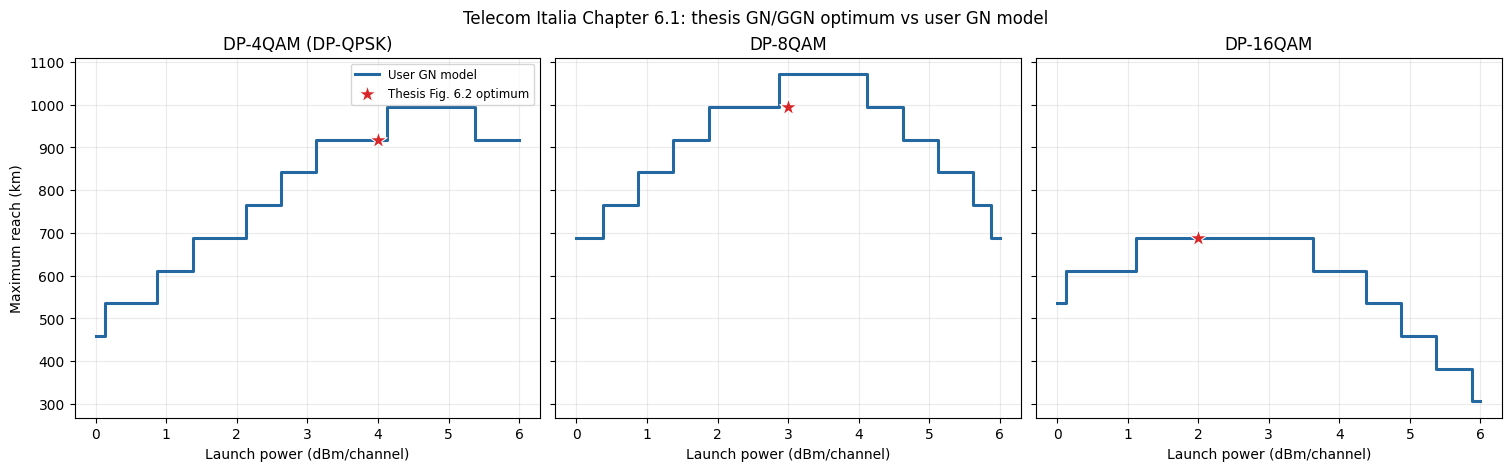

,Format,Paper Popt [dBm/ch],Model optimum plateau [dBm/ch],Model representative Popt [dBm/ch],Paper max spans,Model max spans,Paper max reach [km],Model max reach [km],Reach error [%]
0,DP-4QAM (DP-QPSK),4.0,4.25 to 5.25,4.750,12,13,918.0,994.5,8.333
1,DP-8QAM,3.0,3.00 to 4.00,3.500,13,14,994.5,1071.0,7.692
2,DP-16QAM,2.0,1.25 to 3.50,2.375,9,9,688.5,688.5,0.000


Maximum-reach relative RMSE = 6.548%
Telecom Italia Figure 6.2 reach validation: PASS (<10% at every modulation)


In [6]:
tim_paper_power_dbm = np.arange(0.0, 6.0001, 0.25)
tim_paper_fiber = TIM_FIBERS["Paper"]
tim_paper_results = {}
tim_validation_rows = []

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.6), sharey=True, layout="constrained")
for ax, (key, modulation) in zip(axes, TIM_MODULATIONS.items()):
    result_tim = tim_reach_curve(
        tim_paper_fiber, modulation, tim_paper_power_dbm, max_spans=30
    )
    tim_paper_results[key] = result_tim
    paper_reach_km = modulation.paper_max_spans * TIM_SPAN_LENGTH_KM
    reach_error_percent = (
        100.0 * (result_tim["maximum_reach_km"] - paper_reach_km)
        / paper_reach_km
    )
    pmin, pmax = result_tim["optimum_plateau_dbm"]
    tim_validation_rows.append({
        "Format": modulation.label,
        "Paper Popt [dBm/ch]": modulation.paper_optimum_dbm,
        "Model optimum plateau [dBm/ch]": f"{pmin:.2f} to {pmax:.2f}",
        "Model representative Popt [dBm/ch]": result_tim["representative_optimum_dbm"],
        "Paper max spans": modulation.paper_max_spans,
        "Model max spans": result_tim["maximum_spans"],
        "Paper max reach [km]": paper_reach_km,
        "Model max reach [km]": result_tim["maximum_reach_km"],
        "Reach error [%]": reach_error_percent,
    })

    ax.step(
        result_tim["launch_dbm"], result_tim["max_reach_km"], where="mid",
        lw=2.2, color="#2468a2", label="User GN model"
    )
    ax.scatter(
        [modulation.paper_optimum_dbm], [paper_reach_km],
        marker="*", s=170, color="#d62728", edgecolor="white", linewidth=0.8,
        zorder=5, label="Thesis Fig. 6.2 optimum"
    )
    ax.set_title(modulation.label)
    ax.set_xlabel("Launch power (dBm/channel)")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("Maximum reach (km)")
axes[0].legend(fontsize=8.5)
fig.suptitle("Telecom Italia Chapter 6.1: thesis GN/GGN optimum vs user GN model")
fig.savefig("telecom_italia_paper_vs_user_gn.png", dpi=220, bbox_inches="tight")
plt.show()

tim_validation_df = pd.DataFrame(tim_validation_rows)
display(tim_validation_df.round(3))

tim_reach_rmse_percent = float(
    np.sqrt(np.mean(tim_validation_df["Reach error [%]"] ** 2))
)
print(f"Maximum-reach relative RMSE = {tim_reach_rmse_percent:.3f}%")
assert np.max(np.abs(tim_validation_df["Reach error [%]"])) < 10.0
print("Telecom Italia Figure 6.2 reach validation: PASS (<10% at every modulation)")


## 동일 Telecom Italia 조건에서 광섬유 교체 비교

송신기, 변조, 채널수, span 길이, NF와 노드 삽입손실은 그대로 두고 광섬유 물성만 바꾼다. 각 광섬유의 EDFA gain은 `fiber span loss + 1.224 dB node loss`로 재설정한다. 따라서 논문 광섬유의 gain은 부록의 24.174 dB와 정확히 같고, 저손실 광섬유에는 불필요한 과잉 gain을 적용하지 않는다.

이 결과는 증폭기 최대 gain/output, PFE, 필터 누적, PMD/PDL, 접속·수리 margin을 제한하지 않은 **광섬유 물성 중심 비교**이다.


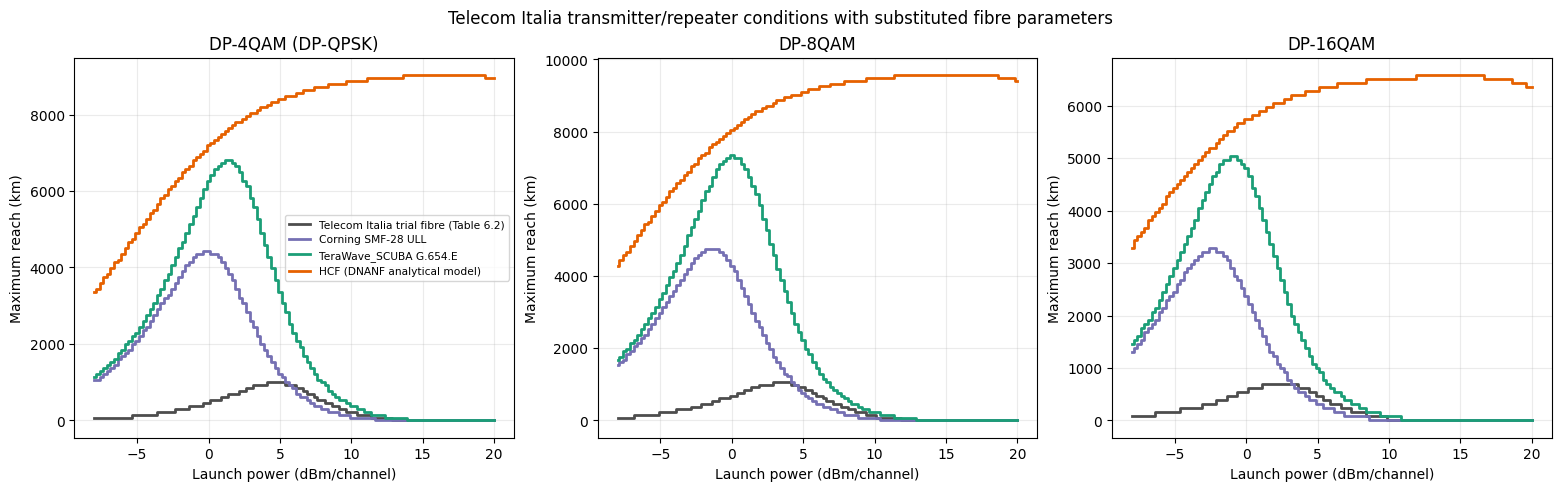

,Format,Fiber,Popt plateau [dBm/ch],Representative Popt [dBm/ch],Maximum spans,Maximum reach [km],Span gain [dB],eta1 [1/W^2]
0,DP-4QAM (DP-QPSK),Telecom Italia trial fibre (Table 6.2),4.25 to 5.25,4.750,13,994.5,24.1740,147.4271
1,DP-4QAM (DP-QPSK),Corning SMF-28 ULL,-0.25 to 0.00,-0.125,58,4437.0,13.1580,281.4904
2,DP-4QAM (DP-QPSK),TeraWave_SCUBA G.654.E,1.25 to 1.50,1.375,89,6808.5,12.7755,92.3516
3,DP-4QAM (DP-QPSK),HCF (DNANF analytical model),13.75 to 19.25,16.500,118,9027.0,6.9610,0.0005
4,DP-8QAM,Telecom Italia trial fibre (Table 6.2),3.00 to 4.00,3.500,14,1071.0,24.1740,260.2956
5,DP-8QAM,Corning SMF-28 ULL,-1.75 to -1.00,-1.375,62,4743.0,13.1580,500.5539
6,DP-8QAM,TeraWave_SCUBA G.654.E,0.00 to 0.00,0.000,96,7344.0,12.7755,163.8360
7,DP-8QAM,HCF (DNANF analytical model),11.50 to 18.50,15.000,125,9562.5,6.9610,0.0009
8,DP-16QAM,Telecom Italia trial fibre (Table 6.2),1.25 to 3.50,2.375,9,688.5,24.1740,431.8098
9,DP-16QAM,Corning SMF-28 ULL,-2.50 to -2.25,-2.375,43,3289.5,13.1580,816.8207


,Format,Fiber,Maximum reach [km],vs G.654.E [km],vs G.654.E [%]
0,DP-4QAM (DP-QPSK),Corning SMF-28 ULL,4437.0,-2371.5,-34.83
1,DP-4QAM (DP-QPSK),TeraWave_SCUBA G.654.E,6808.5,0.0,0.00
2,DP-4QAM (DP-QPSK),HCF (DNANF analytical model),9027.0,2218.5,32.58
3,DP-8QAM,Corning SMF-28 ULL,4743.0,-2601.0,-35.42
4,DP-8QAM,TeraWave_SCUBA G.654.E,7344.0,0.0,0.00
5,DP-8QAM,HCF (DNANF analytical model),9562.5,2218.5,30.21
6,DP-16QAM,Corning SMF-28 ULL,3289.5,-1759.5,-34.85
7,DP-16QAM,TeraWave_SCUBA G.654.E,5049.0,0.0,0.00
8,DP-16QAM,HCF (DNANF analytical model),6579.0,1530.0,30.30


NOTE: HCF includes distributed IMI=-52 dB/km; the two solid-core fibres use IMI=0.
Telecom Italia fibre substitution sweep: PASS


In [7]:
tim_fiber_power_dbm = np.arange(-8.0, 20.0001, 0.25)
tim_fiber_results = {}
tim_fiber_summary_rows = []

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), sharey=False, layout="constrained")
for ax, (mod_key, modulation) in zip(axes, TIM_MODULATIONS.items()):
    tim_fiber_results[mod_key] = {}
    for fiber_key in ("Paper", "SMF", "G654E", "HCF"):
        fiber = TIM_FIBERS[fiber_key]
        result_tim = tim_reach_curve(
            fiber, modulation, tim_fiber_power_dbm, max_spans=TIM_MAX_SPANS
        )
        tim_fiber_results[mod_key][fiber_key] = result_tim
        pmin, pmax = result_tim["optimum_plateau_dbm"]
        tim_fiber_summary_rows.append({
            "Format": modulation.label,
            "Fiber": fiber.label,
            "Popt plateau [dBm/ch]": f"{pmin:.2f} to {pmax:.2f}",
            "Representative Popt [dBm/ch]": result_tim["representative_optimum_dbm"],
            "Maximum spans": result_tim["maximum_spans"],
            "Maximum reach [km]": result_tim["maximum_reach_km"],
            "Span gain [dB]": tim_span_gain_db(fiber),
            "eta1 [1/W^2]": result_tim["eta_single_span"],
        })
        ax.step(
            result_tim["launch_dbm"], result_tim["max_reach_km"],
            where="mid", lw=2.0, color=fiber.color, label=fiber.label
        )
    ax.set_title(modulation.label)
    ax.set_xlabel("Launch power (dBm/channel)")
    ax.set_ylabel("Maximum reach (km)")
    ax.grid(True, alpha=0.25)
axes[0].legend(fontsize=7.7)
fig.suptitle(
    "Telecom Italia transmitter/repeater conditions with substituted fibre parameters"
)
fig.savefig("telecom_italia_fiber_comparison.png", dpi=220, bbox_inches="tight")
plt.show()

tim_fiber_summary_df = pd.DataFrame(tim_fiber_summary_rows)
display(tim_fiber_summary_df.round(4))

tim_relative_rows = []
for mod_key, modulation in TIM_MODULATIONS.items():
    g654 = tim_fiber_results[mod_key]["G654E"]["maximum_reach_km"]
    for fiber_key in ("SMF", "G654E", "HCF"):
        reach = tim_fiber_results[mod_key][fiber_key]["maximum_reach_km"]
        tim_relative_rows.append({
            "Format": modulation.label,
            "Fiber": TIM_FIBERS[fiber_key].label,
            "Maximum reach [km]": reach,
            "vs G.654.E [km]": reach - g654,
            "vs G.654.E [%]": 100.0 * (reach - g654) / g654,
        })
tim_relative_df = pd.DataFrame(tim_relative_rows)
display(tim_relative_df.round(2))

print("NOTE: HCF includes distributed IMI=-52 dB/km; the two solid-core fibres use IMI=0.")
assert np.all(np.isfinite(tim_fiber_summary_df["Maximum reach [km]"]))
print("Telecom Italia fibre substitution sweep: PASS")


## 자동 결론

아래 셀은 해저 리피터 비교, Chapter 6.1 재현 오차, 동일 TIM 조건의 광섬유 교체 결과를 논문 작성에 바로 옮길 수 있는 문장으로 출력한다.


In [8]:
g654_required = comparison["required_repeaters"]["G654E"]
hcf_required = comparison["required_repeaters"]["HCF"]
common_rep = comparison["common_repeater_count"]

print("=" * 92)
print("FINAL RESULTS")
print("=" * 92)
print(
    f"[Submarine / 1,000 km / 40 Tb/s] HCF={hcf_required} repeaters, "
    f"TeraWave_SCUBA G.654.E={g654_required} repeaters -> "
    f"reduction={comparison['repeater_reduction']} "
    f"({comparison['repeater_reduction_percent']:.2f}%)."
)
print(
    f"[Equal route and repeaters] At {common_rep} repeaters, HCF capacity gain vs G.654.E="
    f"{comparison['capacity_gain_tbps']:+.3f} Tb/s "
    f"({comparison['capacity_gain_percent']:+.2f}%)."
)
print(f"[TIM paper validation] Reach relative RMSE={tim_reach_rmse_percent:.3f}%.")

for mod_key, modulation in TIM_MODULATIONS.items():
    paper_result = tim_paper_results[mod_key]
    pmin, pmax = paper_result["optimum_plateau_dbm"]
    print(
        f"[{modulation.label}] thesis={modulation.paper_optimum_dbm:.1f} dBm/ch, "
        f"{modulation.paper_max_spans} spans ({modulation.paper_max_spans*TIM_SPAN_LENGTH_KM:.1f} km); "
        f"user GN plateau={pmin:.2f}..{pmax:.2f} dBm/ch, "
        f"{paper_result['maximum_spans']} spans ({paper_result['maximum_reach_km']:.1f} km)."
    )

display(Markdown(
    """
### 해석 시 주의사항

- Chapter 6.1 검증은 thesis Figure 6.2의 **GN/GGN 시뮬레이션 최적점**과의 비교이며, 본문에 인용된 실제 측정 최적점과는 구분된다.
- 사용자 GN 모델은 단일-span 수치 적분 후 `Nspan^(1+0.05)`로 누적한다. 논문의 exact coherent 적분보다 DP-4QAM·DP-8QAM 도달거리를 다소 크게 예측하는 것이 정상적인 모델 차이다.
- HCF 교체 결과는 IMI -52 dB/km를 포함한다. IMI를 0으로 두면 매우 긴 이론 도달거리가 나오므로, 상용 설계 결론으로 사용해서는 안 된다.
- 해저 리피터 결과 또한 최대 증폭기 이득·출력, PFE 및 운용 margin을 제한하지 않은 이론 비교다.
"""
))


FINAL RESULTS
[Submarine / 1,000 km / 40 Tb/s] HCF=1 repeaters, TeraWave_SCUBA G.654.E=6 repeaters -> reduction=5 (83.33%).
[Equal route and repeaters] At 6 repeaters, HCF capacity gain vs G.654.E=+6.077 Tb/s (+14.37%).
[TIM paper validation] Reach relative RMSE=6.548%.
[DP-4QAM (DP-QPSK)] thesis=4.0 dBm/ch, 12 spans (918.0 km); user GN plateau=4.25..5.25 dBm/ch, 13 spans (994.5 km).
[DP-8QAM] thesis=3.0 dBm/ch, 13 spans (994.5 km); user GN plateau=3.00..4.00 dBm/ch, 14 spans (1071.0 km).
[DP-16QAM] thesis=2.0 dBm/ch, 9 spans (688.5 km); user GN plateau=1.25..3.50 dBm/ch, 9 spans (688.5 km).



### 해석 시 주의사항

- Chapter 6.1 검증은 thesis Figure 6.2의 **GN/GGN 시뮬레이션 최적점**과의 비교이며, 본문에 인용된 실제 측정 최적점과는 구분된다.
- 사용자 GN 모델은 단일-span 수치 적분 후 `Nspan^(1+0.05)`로 누적한다. 논문의 exact coherent 적분보다 DP-4QAM·DP-8QAM 도달거리를 다소 크게 예측하는 것이 정상적인 모델 차이다.
- HCF 교체 결과는 IMI -52 dB/km를 포함한다. IMI를 0으로 두면 매우 긴 이론 도달거리가 나오므로, 상용 설계 결론으로 사용해서는 안 된다.
- 해저 리피터 결과 또한 최대 증폭기 이득·출력, PFE 및 운용 margin을 제한하지 않은 이론 비교다.


## 모델 참고문헌

1. R. Sohanpal *et al.*, “On the Optimum Energy-per-bit Launch Power in Coherent Hollow-core Fibre Transmission Systems,” 2026.
2. P. Poggiolini and F. Poletti, “Opportunities and Challenges for Long-Distance Transmission in Hollow-Core Fibres,” *J. Lightwave Technol.*, 40(6), 1605–1616 (2022), DOI: 10.1109/JLT.2021.3140114.
3. M. I. Hasan *et al.*, “Analytical model of the effective modal refractive index of the LP01 mode of non-ideal hollow-core anti-resonant fibers,” arXiv:1708.06879.


### Telecom Italia 분석 자료

- A. Alonso, *Generalized Gaussian Noise Model*, Master Thesis, Politecnico di Torino / Universidad Politécnica de Madrid, Chapter 6.1 “Telecom Italia Field Trial,” Tables 6.1-6.3, Figure 6.2, and Appendix `systemParams` case `TIM`, 2018.
- Chapter 6.1이 인용한 field-trial 원문 [5]의 측정 최적점은 thesis 본문에 요약된 값을 사용하고, 그래프 정밀도 평가는 thesis Figure 6.2의 GN/GGN 결과를 기준으로 한다.
